In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import shap
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Diabetes_Dataset.csv")
df.columns = df.columns.str.strip()

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)

In [4]:
df['Glucose_BMI'] = df['Glucose'] * df['BMI']
df['Age_BMI'] = df['Age'] * df['BMI']
df['Preg_Age'] = df['Pregnancies'] * df['Age']

In [5]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
imputer = KNNImputer(n_neighbors=5)

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

In [8]:
scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [9]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [10]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154


Random Forest
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       100
           1       0.59      0.70      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154


SVM
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       100
           1       0.62      0.74      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.76      0.75

In [11]:
best_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [12]:
y_prob = best_model.predict_proba(X_test)[:, 1]

y_custom = (y_prob > 0.35).astype(int)

print("Final Model with Threshold 0.35")
print(classification_report(y_test, y_custom))

Final Model with Threshold 0.35
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       100
           1       0.61      0.78      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.75       154



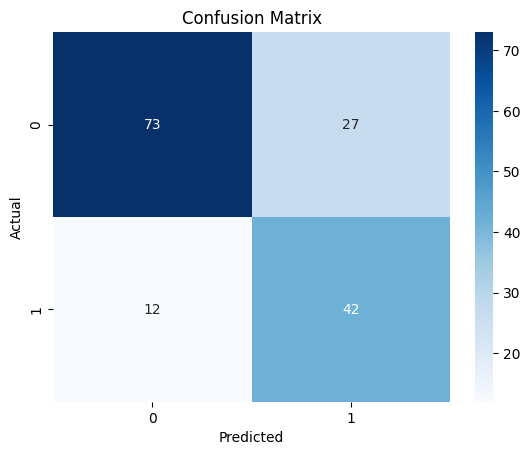

In [13]:
cm = confusion_matrix(y_test, y_custom)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

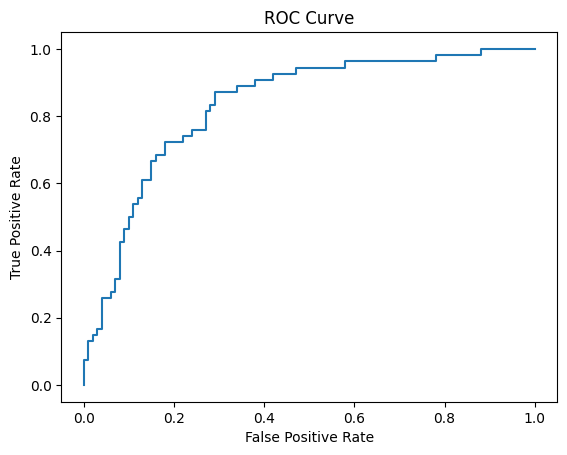

ROC-AUC: 0.832962962962963


In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss'
    ))
])

scores = cross_val_score(pipeline, X, y, cv=skf, scoring='recall')

print("Recall Scores:", scores)
print("Mean Recall:", scores.mean())

Recall Scores: [0.66666667 0.64814815 0.57407407 0.60377358 0.58490566]
Mean Recall: 0.6155136268343815


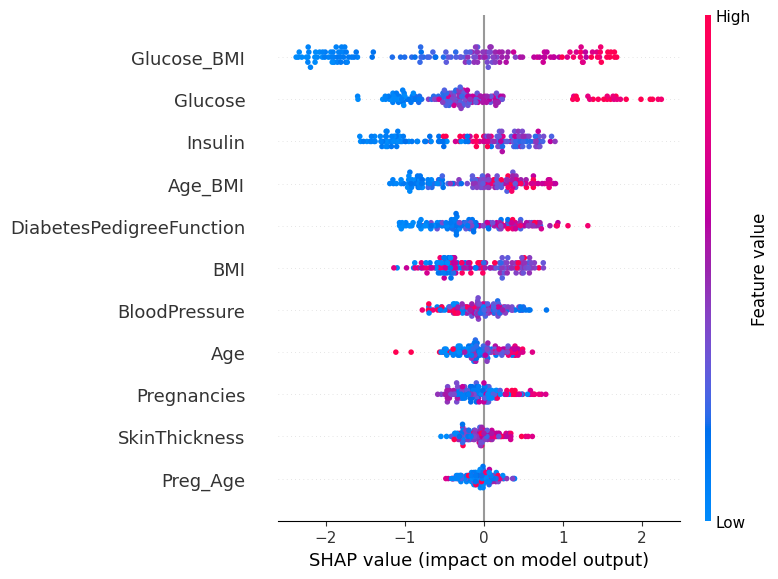

In [16]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [17]:
risk_scores = best_model.predict_proba(X_test)[:, 1]

for i in range(5):
    print(f"Patient {i}: Risk Score = {risk_scores[i]:.2f}")

Patient 0: Risk Score = 0.94
Patient 1: Risk Score = 0.02
Patient 2: Risk Score = 0.07
Patient 3: Risk Score = 0.73
Patient 4: Risk Score = 0.00


In [18]:
for i in range(5):
    risk = risk_scores[i]

    if risk > 0.7:
        status = "High Risk ⚠️"
    elif risk > 0.4:
        status = "Moderate Risk"
    else:
        status = "Low Risk"

    print(f"Patient {i}: Risk Score = {risk:.2f} → {status}")

Patient 0: Risk Score = 0.94 → High Risk ⚠️
Patient 1: Risk Score = 0.02 → Low Risk
Patient 2: Risk Score = 0.07 → Low Risk
Patient 3: Risk Score = 0.73 → High Risk ⚠️
Patient 4: Risk Score = 0.00 → Low Risk


In [19]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test.values[:5],
    "Predicted Probability": risk_scores[:5],
    "Predicted Class": (risk_scores[:5] > 0.35).astype(int)
})

print(results)

   Actual  Predicted Probability  Predicted Class
0       0               0.935253                1
1       0               0.021464                0
2       0               0.072719                0
3       1               0.726201                1
4       0               0.000604                0


In [20]:
import pickle

# Save model
with open("Diabetes.pkl", "wb") as file:
    pickle.dump(model, file)



In [21]:
from google.colab import files

files.download("Diabetes.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>